## Windkessel-Informed Neural Network for Cuffless BP Estimation 
==========================================================================

Physics constraint: 2-element Windkessel diastolic decay equation
 ##   DBP = SBP * exp(-decay_time / RC) ##
 
This constrains DBP to be consistent with the model's own SBP prediction
and the measured diastolic decay time (systolic peak -> dicrotic notch).
SBP remains purely data-driven (see explanation in accompanying chat message).
 
Sections:

    -  Peak / dicrotic notch detection  (feature extraction from raw PPG)

    -  RC estimation                    (fit once from training data)

    -  Windkessel physics loss          (the actual PINN constraint)

    - Model architecture               (simple 1D CNN)

    - Training loop                    (combines data loss + physics loss)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import (
    find_peaks,
    savgol_filter
)
import h5py

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader

## Peak / Dicrotic Notch detection ##

Systolic peak = start of the "pressure is falling" phase, and dicrotic notch = the precise physiological start of diastole, where the heart is no longer pushing anything in.

For this eqn - P(t) = P_sys · exp(-t / RC)

We need t = decay time, which is simply the number of seconds it takes for arterial pressure to go from its systolic peak down to the start of the diastolic (passive) phase, measured as the time gap between the systolic peak and the dicrotic notch on the PPG waveform.

In [3]:
def get_systolic_peak(ppg_window, fs=125):

    peaks, properties = find_peaks(
        ppg_window,
        height=np.mean(ppg_window),
        distance=int(0.3 * fs),
        prominence=0.1
    )

    if len(peaks) == 0:
        return np.array([], dtype=int)

    return peaks

In [4]:
def calculate_derivatives(ppg, fs=125):

    # -----------------------------------
    # Smooth PPG
    # -----------------------------------

    smooth_ppg = savgol_filter(
        ppg,
        window_length=15,
        polyorder=3
    )

    # -----------------------------------
    # First derivative = VPG
    # -----------------------------------

    vpg = np.gradient(
        smooth_ppg
    ) * fs

    # -----------------------------------
    # Second derivative = APG
    # -----------------------------------

    apg = np.gradient(
        vpg
    ) * fs

    return smooth_ppg, vpg, apg

In [5]:
def get_dicrotic_notch(
    ppg_window,
    sys_idx,
    fs=125
):

    if sys_idx is None:
        return None

    smooth_ppg, vpg, apg = calculate_derivatives(
        ppg_window,
        fs
    )

    # ==================================================
    # 1. Restrict search to early falling limb
    # ==================================================

    search_start = (
        sys_idx + int(0.08 * fs)
    )

    search_end = (
        sys_idx + int(0.30 * fs)
    )

    search_end = min(
        search_end,
        len(ppg_window) - 1
    )

    if search_start >= search_end:
        return None


    # ==================================================
    # 2. Look at APG in this region
    # ==================================================

    apg_segment = apg[
        search_start:search_end
    ]


    # ==================================================
    # 3. Find APG extrema
    # ==================================================

    extrema, _ = find_peaks(
        np.abs(apg_segment),
        prominence=np.std(apg_segment) * 0.15
    )

    if len(extrema) == 0:
        return None


    candidates = (
        search_start + extrema
    )


    # ==================================================
    # 4. Keep only candidates on falling limb
    # ==================================================

    valid_candidates = []

    for idx in candidates:

        # PPG should still be descending
        if vpg[idx] < 0:

            valid_candidates.append(idx)


    if len(valid_candidates) == 0:
        return None


    # ==================================================
    # 5. Find the FIRST meaningful slope change
    # ==================================================

    best_candidate = None

    for idx in valid_candidates:

        left_start = max(
            sys_idx,
            idx - int(0.025 * fs)
        )

        right_end = min(
            len(vpg),
            idx + int(0.025 * fs)
        )

        if idx <= left_start:
            continue

        if idx >= right_end:
            continue


        left_vpg = np.mean(
            vpg[left_start:idx]
        )

        right_vpg = np.mean(
            vpg[idx:right_end]
        )


        slope_change = abs(
            right_vpg - left_vpg
        )


        # Require meaningful change
        threshold = (
            0.15 * np.std(vpg)
        )


        if slope_change > threshold:

            best_candidate = idx

            # IMPORTANT:
            # Take the FIRST meaningful candidate
            break


    return best_candidate

In [6]:
def get_decay_time(ppg_window, fs=125):
    """
    Returns diastolic decay time (systolic peak -> dicrotic notch), in seconds.
    Returns None if either landmark could not be detected (caller should
    skip / fall back to a dataset-median value for that sample).
    """
    sys_idx = get_systolic_peak(ppg_window, fs)
    notch_idx = get_dicrotic_notch(ppg_window, sys_idx, fs)
    if sys_idx is None or notch_idx is None:
        return None
    return (notch_idx - sys_idx) / fs

In [7]:
def extract_decay_times(ppg_windows, fs=125, fallback='median'):
    """
    Runs decay-time extraction over a full array of PPG windows (N, L).
    Failed detections are filled with the median of successful ones.
    Returns: np.array of shape (N,)
    """
    decay_times = []
    for w in ppg_windows:
        dt = get_decay_time(w, fs)
        decay_times.append(dt)
 
    decay_times = np.array([d if d is not None else np.nan for d in decay_times])
    valid = decay_times[~np.isnan(decay_times)]
    if fallback == 'median' and len(valid) > 0:
        med = np.median(valid)
        decay_times = np.where(np.isnan(decay_times), med, decay_times)
    return decay_times.astype(np.float32)

In [13]:
FS = 125
WINDOW_SIZE = 1000

MAT_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/data/Part_1.mat"
f = h5py.File(MAT_PATH, "r")

dataset = f["Part_1"]

print("Number of recordings:", dataset.shape[0])
ref = dataset[0, 0]

recording = f[ref][:]

print("Recording shape:", recording.shape)
ppg = recording[:, 0]
abp = recording[:, 1]

print("PPG length:", len(ppg))
print("ABP length:", len(abp))
ppg_std = np.std(ppg)

if ppg_std == 0:
    raise ValueError("PPG signal is flat.")

ppg = (ppg - np.mean(ppg)) / ppg_std
START = 0

ppg_window = ppg[
    START:START + WINDOW_SIZE
]

print("Window shape:", ppg_window.shape)


# ==========================================
# Detect ALL systolic peaks
# ==========================================

sys_peaks = get_systolic_peak(
    ppg_window,
    FS
)

print(
    "Number of systolic peaks:",
    len(sys_peaks)
)

print(
    "Systolic peak indices:",
    sys_peaks
)


# ==========================================
# Find notch after EACH systolic peak
# ==========================================

notches = []

for sys_idx in sys_peaks:

    notch_idx = get_dicrotic_notch(
        ppg_window,
        sys_idx,
        FS
    )

    notches.append(notch_idx)


# ==========================================
# Print results
# ==========================================

print("\nDetected landmarks:")

for i, (sys_idx, notch_idx) in enumerate(
    zip(sys_peaks, notches)
):

    print(
        f"Beat {i+1}: "
        f"Systolic = {sys_idx} "
        f"({sys_idx / FS:.3f} s), "
        f"Notch = {notch_idx}"
    )


# ==========================================
# Calculate delays
# ==========================================

delay_times = []

for sys_idx, notch_idx in zip(
    sys_peaks,
    notches
):

    if notch_idx is None:
        delay_times.append(np.nan)

    else:

        delay = (
            notch_idx - sys_idx
        ) / FS

        delay_times.append(delay)


delay_times = np.array(
    delay_times,
    dtype=np.float32
)


print("\nPeak → notch delays:")

for i, delay in enumerate(delay_times):

    if np.isnan(delay):

        print(
            f"Beat {i+1}: Detection failed"
        )

    else:

        print(
            f"Beat {i+1}: "
            f"{delay:.3f} seconds"
        )


Number of recordings: 3000
Recording shape: (61000, 3)
PPG length: 61000
ABP length: 61000
Window shape: (1000,)
Number of systolic peaks: 16
Systolic peak indices: [ 45 107 170 231 292 355 416 477 537 598 659 720 780 839 899 960]

Detected landmarks:
Beat 1: Systolic = 45 (0.360 s), Notch = 62
Beat 2: Systolic = 107 (0.856 s), Notch = 124
Beat 3: Systolic = 170 (1.360 s), Notch = 186
Beat 4: Systolic = 231 (1.848 s), Notch = 248
Beat 5: Systolic = 292 (2.336 s), Notch = 310
Beat 6: Systolic = 355 (2.840 s), Notch = 373
Beat 7: Systolic = 416 (3.328 s), Notch = 434
Beat 8: Systolic = 477 (3.816 s), Notch = 493
Beat 9: Systolic = 537 (4.296 s), Notch = 553
Beat 10: Systolic = 598 (4.784 s), Notch = 614
Beat 11: Systolic = 659 (5.272 s), Notch = 675
Beat 12: Systolic = 720 (5.760 s), Notch = 736
Beat 13: Systolic = 780 (6.240 s), Notch = 797
Beat 14: Systolic = 839 (6.712 s), Notch = 854
Beat 15: Systolic = 899 (7.192 s), Notch = 915
Beat 16: Systolic = 960 (7.680 s), Notch = 976

Peak →

In [24]:
def extract_bp_from_abp(abp_window):

    # --------------------------------------------------------
    # Detect systolic peaks in ABP
    # --------------------------------------------------------

    peaks, _ = find_peaks(
        abp_window,
        distance=50,
        prominence=5
    )


    # Need at least two beats
    if len(peaks) < 2:
        return None, None


    # --------------------------------------------------------
    # SBP
    # --------------------------------------------------------

    sbp_values = abp_window[peaks]


    # --------------------------------------------------------
    # DBP
    # --------------------------------------------------------

    dbp_values = []


    for i in range(len(peaks) - 1):

        beat_segment = abp_window[
            peaks[i]:peaks[i + 1]
        ]

        if len(beat_segment) > 0:

            dbp_values.append(
                np.min(beat_segment)
            )


    if len(dbp_values) == 0:
        return None, None


    # --------------------------------------------------------
    # Median across beats
    # --------------------------------------------------------

    sbp = np.median(
        sbp_values
    )

    dbp = np.median(
        dbp_values
    )


    # --------------------------------------------------------
    # Sanity checks
    # --------------------------------------------------------

    if sbp < 50 or sbp > 250:
        return None, None

    if dbp < 20 or dbp > 150:
        return None, None

    if dbp >= sbp:
        return None, None


    return (
        sbp,
        dbp
    )


Number of systolic peaks: 16
Systolic peaks: [ 45 107 170 231 292 355 416 477 537 598 659 720 780 839 899 960]


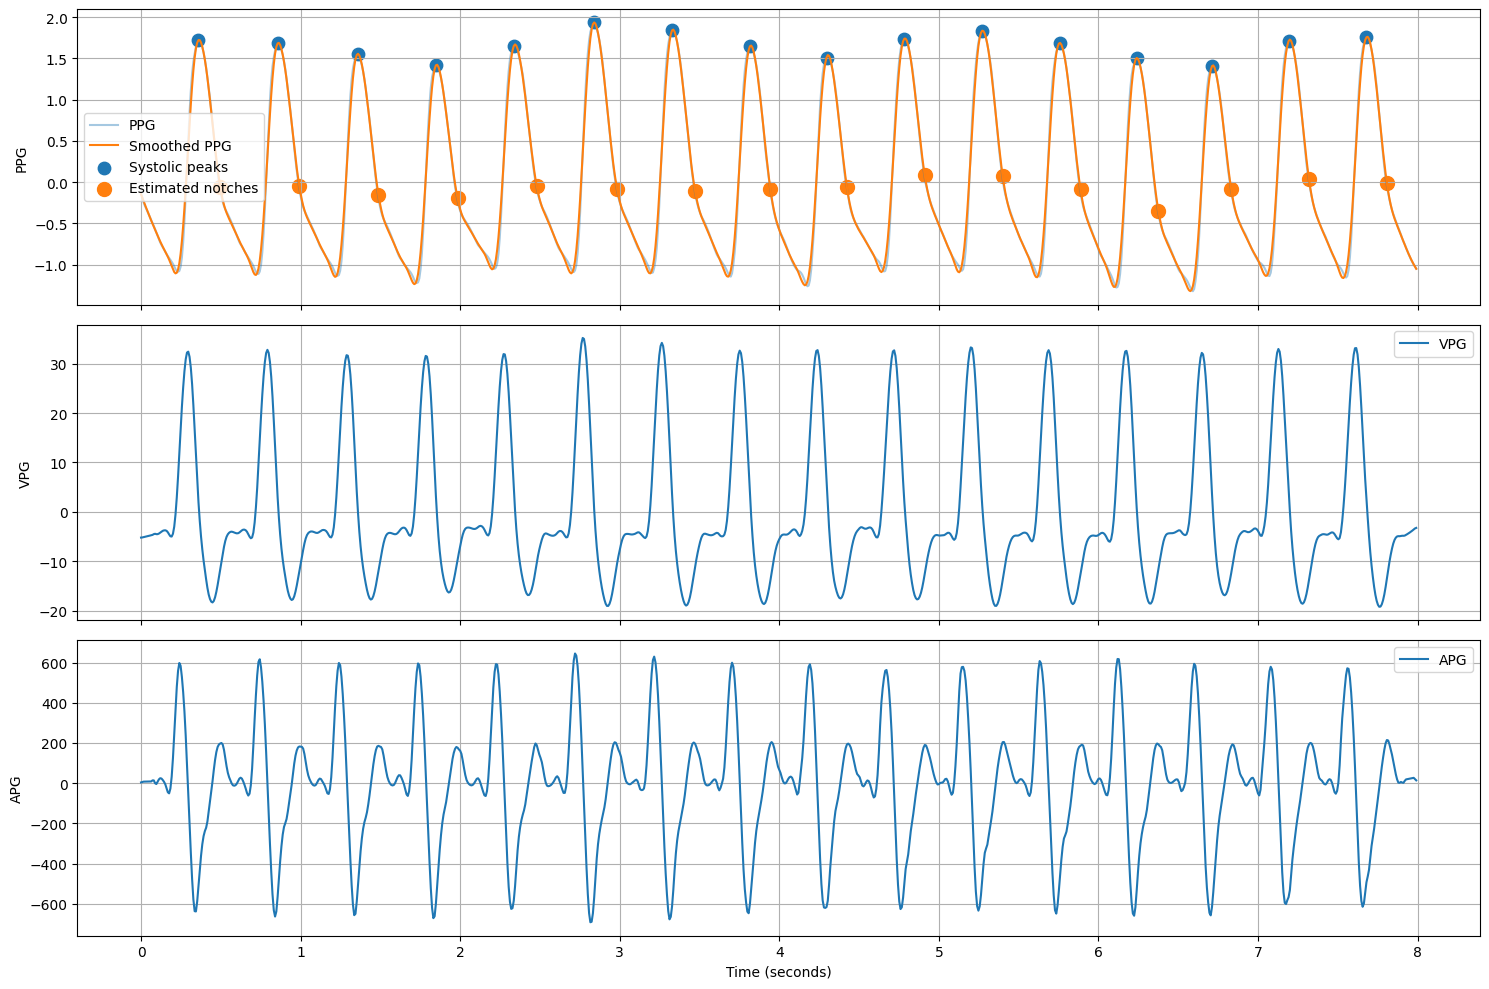

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ==================================================
# Parameters
# ==================================================

FS = 125

# ==================================================
# Smooth PPG
# ==================================================

smooth_ppg = savgol_filter(
    ppg_window,
    window_length=21,
    polyorder=3
)

# ==================================================
# Calculate derivatives
# ==================================================

vpg = np.gradient(smooth_ppg) * FS
apg = np.gradient(vpg) * FS

# ==================================================
# Detect ALL systolic peaks
# ==================================================

sys_peaks = get_systolic_peak(
    ppg_window,
    FS
)

print("Number of systolic peaks:", len(sys_peaks))
print("Systolic peaks:", sys_peaks)


# ==================================================
# Detect notch for EACH peak
# ==================================================

notches = []

for sys_idx in sys_peaks:

    notch_idx = get_dicrotic_notch(
        ppg_window,
        sys_idx,
        FS
    )

    notches.append(notch_idx)


# ==================================================
# Time axis
# ==================================================

time = np.arange(
    len(ppg_window)
) / FS


# ==================================================
# Plot
# ==================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)


# ==================================================
# PPG
# ==================================================

axes[0].plot(
    time,
    ppg_window,
    alpha=0.4,
    label="PPG"
)

axes[0].plot(
    time,
    smooth_ppg,
    label="Smoothed PPG"
)


# All systolic peaks

axes[0].scatter(
    sys_peaks / FS,
    smooth_ppg[sys_peaks],
    s=80,
    label="Systolic peaks"
)


# All detected notches

valid_notches = [
    n for n in notches
    if n is not None
]

if len(valid_notches) > 0:

    valid_notches = np.array(
        valid_notches,
        dtype=int
    )

    axes[0].scatter(
        valid_notches / FS,
        smooth_ppg[valid_notches],
        s=100,
        label="Estimated notches"
    )


axes[0].set_ylabel("PPG")
axes[0].legend()
axes[0].grid()


# ==================================================
# VPG
# ==================================================

axes[1].plot(
    time,
    vpg,
    label="VPG"
)

axes[1].set_ylabel("VPG")
axes[1].legend()
axes[1].grid()


# ==================================================
# APG
# ==================================================

axes[2].plot(
    time,
    apg,
    label="APG"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("APG")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
plt.show()

In [15]:
def process_recording(
    recording,
    WINDOW_SIZE,
    STEP_SIZE,
    fs=125
):

    data = recording[:]


    # ------------------------------------------------
    # Extract PPG and ABP
    # ------------------------------------------------

    ppg = data[:, 0]
    abp = data[:, 1]


    # ------------------------------------------------
    # Recording-level normalization
    # ------------------------------------------------

    std = np.std(ppg)

    if std == 0:

        return None, None, None


    ppg = (
        ppg - np.mean(ppg)
    ) / std


    # ------------------------------------------------
    # Window storage
    # ------------------------------------------------

    X = []
    y = []


    # ------------------------------------------------
    # Windowing
    # ------------------------------------------------

    for start in range(
        0,
        len(ppg) - WINDOW_SIZE + 1,
        STEP_SIZE
    ):

        end = (
            start + WINDOW_SIZE
        )


        ppg_window = ppg[
            start:end
        ]

        abp_window = abp[
            start:end
        ]


        # --------------------------------------------
        # Extract SBP / DBP from ABP
        # --------------------------------------------

        sbp, dbp = extract_bp_from_abp(
            abp_window
        )


        if sbp is None:

            continue


        X.append(
            ppg_window
        )

        y.append(
            [sbp, dbp]
        )


    # ------------------------------------------------
    # No valid windows
    # ------------------------------------------------

    if len(X) == 0:

        return None, None, None


    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.float32
    )


    # ------------------------------------------------
    # Extract PPG systolic -> notch delay
    # ------------------------------------------------

    decay_times = extract_decay_times(
        X,
        fs=fs,
        fallback="median"
    )


    return (
        X,
        y,
        decay_times
    )

In [10]:
def process_split(
    record_list,
    WINDOW_SIZE,
    STEP_SIZE
):

    X_all = []
    y_all = []
    decay_all = []

    skipped = 0


    for f, ref in tqdm(
        record_list
    ):

        recording = f[ref]


        X, y, decay_times = process_recording(
            recording,
            WINDOW_SIZE,
            STEP_SIZE
        )


        if X is None:

            skipped += 1

            continue


        X_all.append(X)
        y_all.append(y)
        decay_all.append(decay_times)


    # ------------------------------------------------
    # Concatenate all recordings
    # ------------------------------------------------

    X_all = np.concatenate(
        X_all,
        axis=0
    )

    y_all = np.concatenate(
        y_all,
        axis=0
    )

    decay_all = np.concatenate(
        decay_all,
        axis=0
    )


    print(
        "Skipped recordings:",
        skipped
    )

    print(
        "X shape:",
        X_all.shape
    )

    print(
        "y shape:",
        y_all.shape
    )

    print(
        "Decay-time shape:",
        decay_all.shape
    )


    return (
        X_all,
        y_all,
        decay_all
    )

In [11]:
DATA_PATH = (
    "/data1/yashvi_bhuva/"
    "BP_estimation_using_PPG/"
    "UCI/data"
)
from tqdm import tqdm
from sklearn.model_selection import train_test_split
def load_UCI_dataset(
    WINDOW_SIZE,
    STEP_SIZE,
    data_path=DATA_PATH,
    test_size=0.2,
    val_size=0.1,
    random_state=42
):

    # ========================================================
    # Load recording references
    # ========================================================

    recordings = []


    for part in range(1, 5):

        file_path = (
            f"{data_path}/Part_{part}.mat"
        )


        f = h5py.File(
            file_path,
            "r"
        )


        dataset = f[
            f"Part_{part}"
        ]


        for i in range(
            dataset.shape[0]
        ):

            recordings.append(
                (
                    f,
                    dataset[i, 0]
                )
            )


    print(
        "Total recordings:",
        len(recordings)
    )


    # ========================================================
    # Train / Test split
    # ========================================================

    train_records, test_records = train_test_split(
        recordings,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )


    # ========================================================
    # Train / Validation split
    # ========================================================

    train_records, val_records = train_test_split(
        train_records,
        test_size=val_size,
        random_state=random_state,
        shuffle=True
    )


    print(
        f"Train recordings: "
        f"{len(train_records)}"
    )

    print(
        f"Validation recordings: "
        f"{len(val_records)}"
    )

    print(
        f"Test recordings: "
        f"{len(test_records)}"
    )


    # ========================================================
    # Process recordings
    # ========================================================

    print("\nProcessing training recordings...")

    (
        X_train,
        y_train,
        decay_train
    ) = process_split(
        train_records,
        WINDOW_SIZE,
        STEP_SIZE
    )


    print("\nProcessing validation recordings...")

    (
        X_val,
        y_val,
        decay_val
    ) = process_split(
        val_records,
        WINDOW_SIZE,
        STEP_SIZE
    )


    print("\nProcessing test recordings...")

    (
        X_test,
        y_test,
        decay_test
    ) = process_split(
        test_records,
        WINDOW_SIZE,
        STEP_SIZE
    )


    # ========================================================
    # Add CNN channel dimension
    # ========================================================

    X_train = X_train[:, None, :]
    X_val = X_val[:, None, :]
    X_test = X_test[:, None, :]


    # ========================================================
    # Convert to tensors
    # ========================================================

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_val = torch.tensor(
        X_val,
        dtype=torch.float32
    )

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )


    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    )

    y_val = torch.tensor(
        y_val,
        dtype=torch.float32
    )

    y_test = torch.tensor(
        y_test,
        dtype=torch.float32
    )


    decay_train = torch.tensor(
        decay_train,
        dtype=torch.float32
    )

    decay_val = torch.tensor(
        decay_val,
        dtype=torch.float32
    )

    decay_test = torch.tensor(
        decay_test,
        dtype=torch.float32
    )


    return (
        X_train,
        y_train,
        decay_train,

        X_val,
        y_val,
        decay_val,

        X_test,
        y_test,
        decay_test
    )

In [12]:
FS = 125

WINDOW_SIZE = 1000      # 8 seconds
STEP_SIZE = 500         # 50% overlap

BATCH_SIZE = 64

RANDOM_STATE = 42

TEST_SIZE = 0.20
VAL_SIZE = 0.10
(
    X_train,
    y_train,
    decay_train,

    X_val,
    y_val,
    decay_val,

    X_test,
    y_test,
    decay_test
) = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 8640
Validation recordings: 960
Test recordings: 2400

Processing training recordings...


 58%|█████▊    | 5023/8640 [02:45<01:59, 30.27it/s]


KeyboardInterrupt: 

In [ ]:
print("====================================")
print("DATASET SHAPES")
print("====================================")

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "decay_train:",
    decay_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "y_val:",
    y_val.shape
)

print(
    "decay_val:",
    decay_val.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)

print(
    "decay_test:",
    decay_test.shape
)

DATASET SHAPES
X_train: torch.Size([468372, 1, 1000])
y_train: torch.Size([468372, 2])
decay_train: torch.Size([468372])
X_val: torch.Size([52933, 1, 1000])
y_val: torch.Size([52933, 2])
decay_val: torch.Size([52933])
X_test: torch.Size([133841, 1, 1000])
y_test: torch.Size([133841, 2])
decay_test: torch.Size([133841])


In [ ]:
print("Train delay statistics")
print("----------------------")

print("Min   :", decay_train.min().item())
print("Max   :", decay_train.max().item())
print("Mean  :", decay_train.mean().item())
print("Median:", decay_train.median().item())
print("Std   :", decay_train.std().item())

Train delay statistics
----------------------
Min   : nan
Max   : nan
Mean  : nan
Median: nan
Std   : nan


In [ ]:
print("Total windows:", len(decay_train))

num_nan = torch.isnan(decay_train).sum().item()

print("NaN windows:", num_nan)
print("Valid windows:", len(decay_train) - num_nan)
print("NaN %:", 100 * num_nan / len(decay_train))

Total windows: 468372
NaN windows: 106034
Valid windows: 362338
NaN %: 22.638842629362983


In [ ]:
idx = 0

ppg_window = X_train[idx, 0].numpy()

sys_idx = get_systolic_peak(ppg_window)
notch_idx = get_dicrotic_notch(ppg_window, sys_idx)

print("Systolic:", sys_idx)
print("Notch:", notch_idx)
print("Delay:", get_decay_time(ppg_window))

Systolic: 408
Notch: None
Delay: None


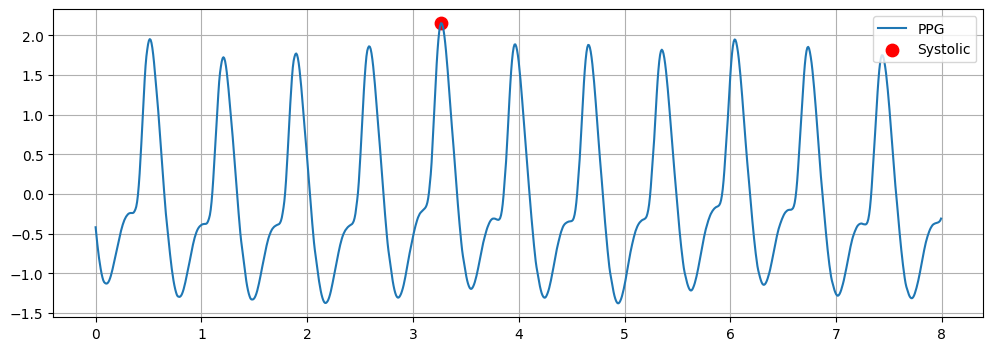

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

t = np.arange(1000) / 125

plt.figure(figsize=(12,4))
plt.plot(t, ppg_window, label="PPG")

if sys_idx is not None:
    plt.scatter(
        t[sys_idx],
        ppg_window[sys_idx],
        c="red",
        s=80,
        label="Systolic"
    )

if notch_idx is not None:
    plt.scatter(
        t[notch_idx],
        ppg_window[notch_idx],
        c="green",
        s=80,
        label="Notch"
    )

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_landmarks(
    X,
    indices,
    fs=125
):

    for idx in indices:

        ppg = X[idx, 0].numpy()

        sys_idx = get_systolic_peak(
            ppg,
            fs
        )

        notch_idx = get_dicrotic_notch(
            ppg,
            sys_idx,
            fs
        )

        time = np.arange(
            len(ppg)
        ) / fs


        plt.figure(figsize=(12, 4))

        plt.plot(
            time,
            ppg,
            label="PPG"
        )


        if sys_idx is not None:

            plt.scatter(
                time[sys_idx],
                ppg[sys_idx],
                s=70,
                label="Systolic peak"
            )


        if notch_idx is not None:

            plt.scatter(
                time[notch_idx],
                ppg[notch_idx],
                s=70,
                label="Dicrotic notch"
            )


        plt.xlabel("Time (s)")
        plt.ylabel("Normalized PPG")

        plt.title(
            f"Window {idx}"
        )

        plt.legend()
        plt.grid()

        plt.show()

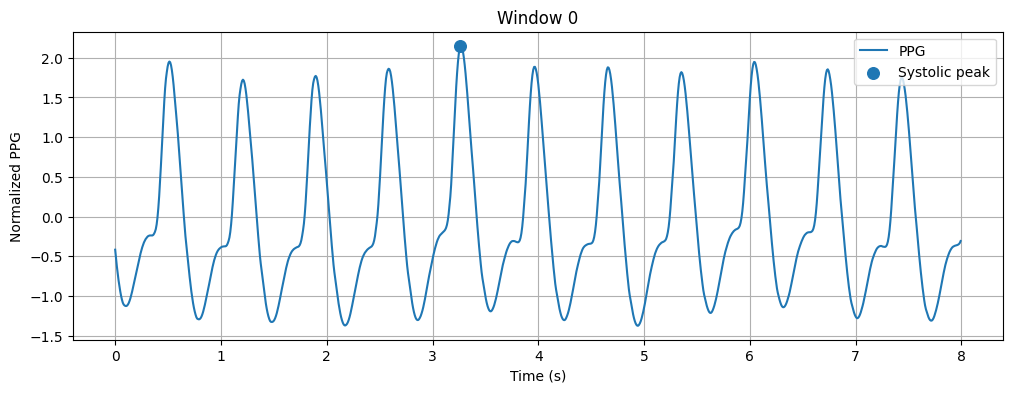

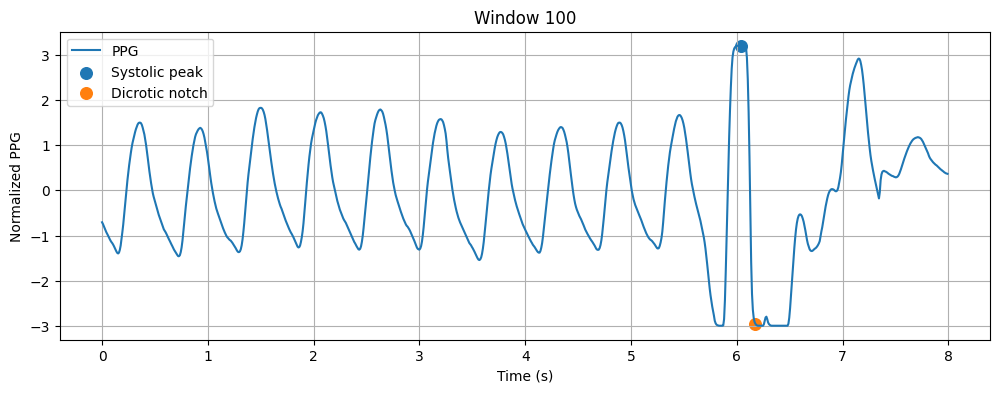

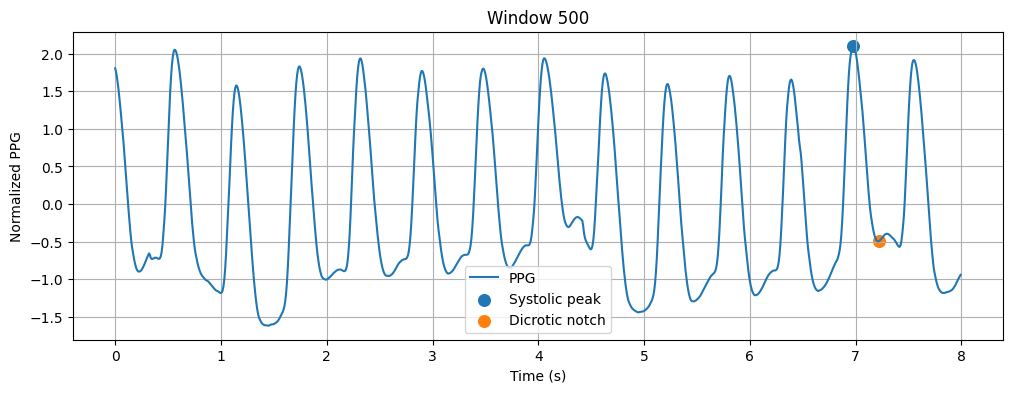

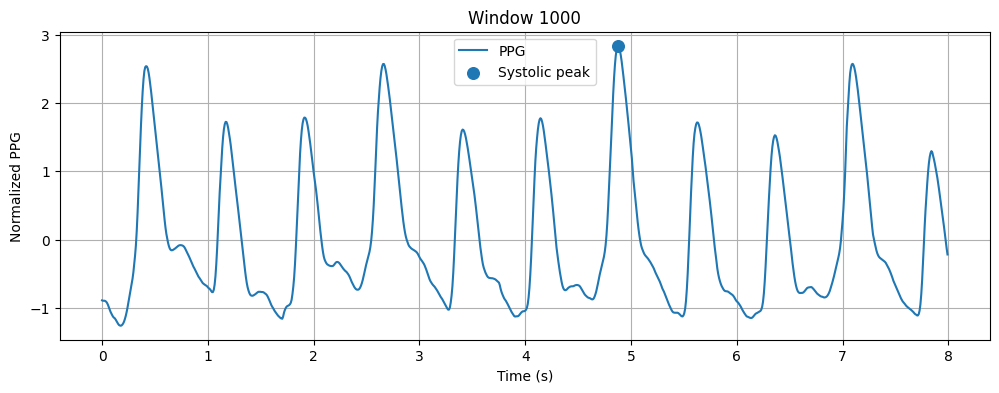

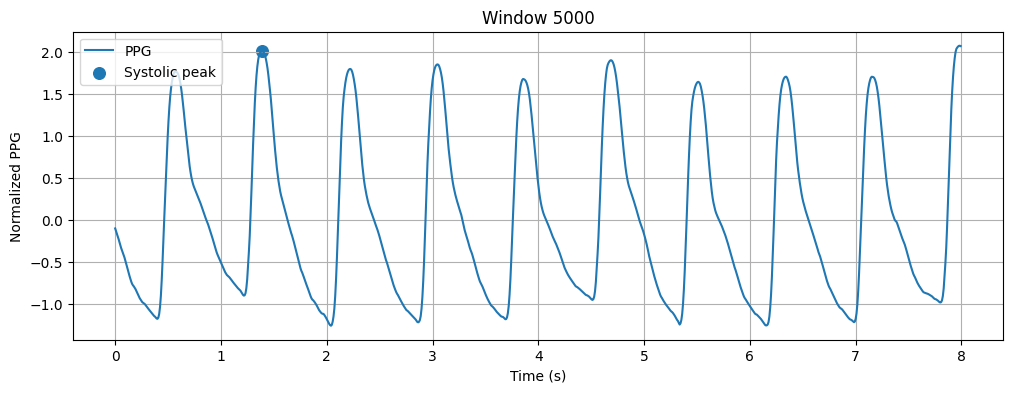

In [ ]:
plot_landmarks(
    X_train,
    [0, 100, 500, 1000, 5000]
)